# Análise: Brasil x Egito (Amistoso)

Bem-vindos! Nesta aula vamos aplicar o extrator que criamos para processar dados brutos consumidos diretamente da API do Sofascore.

In [1]:
import pandas as pd
import json
import glob
import os

import matplotlib.pyplot as plt  # <-- The fix is right here!
import seaborn as sns  # (Assuming you imported seaborn earlier, keeping it here just in case)



# Caminho onde os dados foram salvos pelo nosso script em src/sofascore_extractor.py
# Configurações Globais (Altere aqui para analisar outros jogos ou jogadores)
MATCH_ID = 15186850 # ID da Partida (Egito x Brasil)
TARGET_PLAYER_ID = '868812' # ID do Jogador (Ex: 866469 = Bruno Guimarães)
RAW_DATA_PATH = f'../data/raw/match_{MATCH_ID}'

## 1. Carregando as Escalações
Brasil

In [2]:
with open(os.path.join(RAW_DATA_PATH, 'lineups.json'), 'r', encoding='utf-8') as f:
    lineups = json.load(f)

# Vamos observar quem foram os titulares do Brasil (home team)
brazil_starters = lineups['home']['players']
df_brazil = pd.json_normalize(brazil_starters)
display(df_brazil[['player.name', 'player.position', 'statistics.rating', 'statistics.minutesPlayed']])

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/match_15186850\\lineups.json'

Egito

In [3]:
with open(os.path.join(RAW_DATA_PATH, 'lineups.json'), 'r', encoding='utf-8') as f:
    lineups = json.load(f)

# Vamos observar quem foram os titulares do Egito (away team)
egypto_starters = lineups['away']['players']
df_egypto = pd.json_normalize(egypto_starters)
display(df_egypto[['player.name', 'player.position', 'statistics.rating', 'statistics.minutesPlayed']])

,player.name,player.position,statistics.rating,statistics.minutesPlayed
0,Mostafa Shobeir,G,7.2,90.0
1,Mohamed Hany,D,6.1,75.0
2,Yasser Ibrahim,D,6.9,90.0
3,Hamdy Fathy,M,6.5,90.0
4,Ahmed Fatouh,D,6.2,75.0
5,Mohanad Lasheen,M,6.8,75.0
6,Marwan Attia,M,7.0,85.0
7,Haissem Hassan,M,6.5,45.0
8,Mostafa Ziko,M,7.1,76.0
9,Mahmoud Trézéguet,M,6.4,45.0


## 2. Compilando as Estatísticas Individuais

In [4]:
stats_files = glob.glob(os.path.join(RAW_DATA_PATH, '*_stats.json'))
all_stats = []

# Criar um dicionário de ID para Nome usando a escalação
player_names = {}
for team in ['home', 'away']:
    for p in lineups[team]['players']:
        player_names[str(p['player']['id'])] = p['player']['name']

for file in stats_files:
    # Extrair ID do nome do arquivo (ex: player_123_stats.json)
    player_id = os.path.basename(file).split('_')[1]
    
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        if 'statistics' in data:
            stat = data['statistics']
            # Injetar o ID e o Nome
            stat['player_id'] = player_id
            stat['player_name'] = player_names.get(player_id, f'Player {player_id}')
            
            # Reordenar para o nome aparecer primeiro
            stat_ordered = {'player_id': player_id, 'player_name': stat['player_name']}
            stat_ordered.update(stat)
            
            all_stats.append(stat_ordered)

# Cria um dataframe com as estatísticas completas
df_stats = pd.json_normalize(all_stats)
print(f"Temos estatísticas completas de {len(df_stats)} jogadores!")
df_stats

Temos estatísticas completas de 51 jogadores!


,player_id,player_name,totalPass,accuratePass,goalAssist,totalOwnHalfPasses,accurateOppositionHalfPasses,totalOppositionHalfPasses,duelLost,duelWon,...,wasFouled,shotOffTarget,accurateCross,errorLeadToAGoal,totalKeeperSweeper,accurateKeeperSweeper,clearanceOffLine,outfielderBlock,bigChanceCreated,totalOffside
0,1008171,Ibrahim Adel,9.0,7.0,0.0,1.0,7.0,8.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1013699,Marwan Attia,62.0,50.0,0.0,37.0,18.0,25.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1016907,Igor Thiago,7.0,3.0,0.0,1.0,2.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1035995,Luiz Henrique,12.0,9.0,0.0,1.0,8.0,11.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1048378,Mostafa Shobeir,39.0,31.0,0.0,34.0,1.0,5.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1063327,Hossam Abdelmaguid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1064039,Danilo Oliveira,18.0,12.0,0.0,3.0,9.0,15.0,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1101624,Mahmoud Saber,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1134200,Wesley,7.0,6.0,0.0,5.0,1.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1174937,Endrick,12.0,8.0,0.0,2.0,6.0,10.0,2.0,1.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Visualização de Dados
Vamos cruzar os nomes dos jogadores com suas estatísticas e plotar gráficos.

In [5]:
# A tabela df_stats já possui 'player_id' e 'player_name'.
df_plot = df_stats.copy()

print("=== Lista de Jogadores Disponíveis ===")
# Pegar jogadores do Brasil e do Egito
for _, row in df_plot[['player_id', 'player_name']].drop_duplicates().head(15).iterrows():
    print(f"ID: {row['player_id']} | Nome: {row['player_name']}")
print("... e mais!")

# Filtrar quem jogou pelo menos 1 minuto
df_plot = df_plot[df_plot['minutesPlayed'] > 0]
df_plot.head()

=== Lista de Jogadores Disponíveis ===
ID: 1008171 | Nome: Ibrahim Adel
ID: 1013699 | Nome: Marwan Attia
ID: 1016907 | Nome: Igor Thiago
ID: 1035995 | Nome: Luiz Henrique
ID: 1048378 | Nome: Mostafa Shobeir
ID: 1063327 | Nome: Hossam Abdelmaguid
ID: 1064039 | Nome: Danilo Oliveira
ID: 1101624 | Nome: Mahmoud Saber
ID: 1134200 | Nome: Wesley
ID: 1174937 | Nome: Endrick
ID: 122951 | Nome: Casemiro
ID: 124992 | Nome: Danilo
ID: 1418782 | Nome: Mostafa Ziko
ID: 1464966 | Nome: Rayan
ID: 1480544 | Nome: Tarek Alaa
... e mais!


,player_id,player_name,totalPass,accuratePass,goalAssist,totalOwnHalfPasses,accurateOppositionHalfPasses,totalOppositionHalfPasses,duelLost,duelWon,...,wasFouled,shotOffTarget,accurateCross,errorLeadToAGoal,totalKeeperSweeper,accurateKeeperSweeper,clearanceOffLine,outfielderBlock,bigChanceCreated,totalOffside
0,1008171,Ibrahim Adel,9.0,7.0,0.0,1.0,7.0,8.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1013699,Marwan Attia,62.0,50.0,0.0,37.0,18.0,25.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1016907,Igor Thiago,7.0,3.0,0.0,1.0,2.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1035995,Luiz Henrique,12.0,9.0,0.0,1.0,8.0,11.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1048378,Mostafa Shobeir,39.0,31.0,0.0,34.0,1.0,5.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


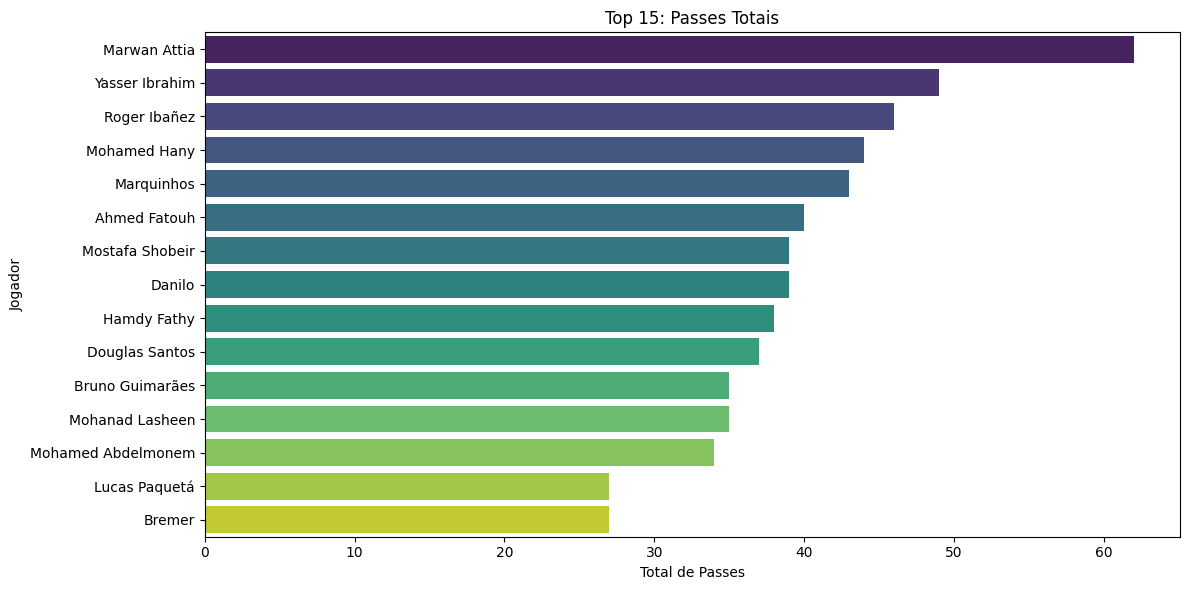

In [ ]:

# Plot: Passes Totais por Jogador
plt.figure(figsize=(12, 6))
df_sorted = df_plot.sort_values(by='totalPass', ascending=False).head(15)
sns.barplot(data=df_sorted, x='totalPass', y='player_name', hue='player_name', legend=False, palette='viridis')
plt.title('Top 15: Passes Totais')
plt.xlabel('Total de Passes')
plt.ylabel('Jogador')
plt.tight_layout()
plt.show()

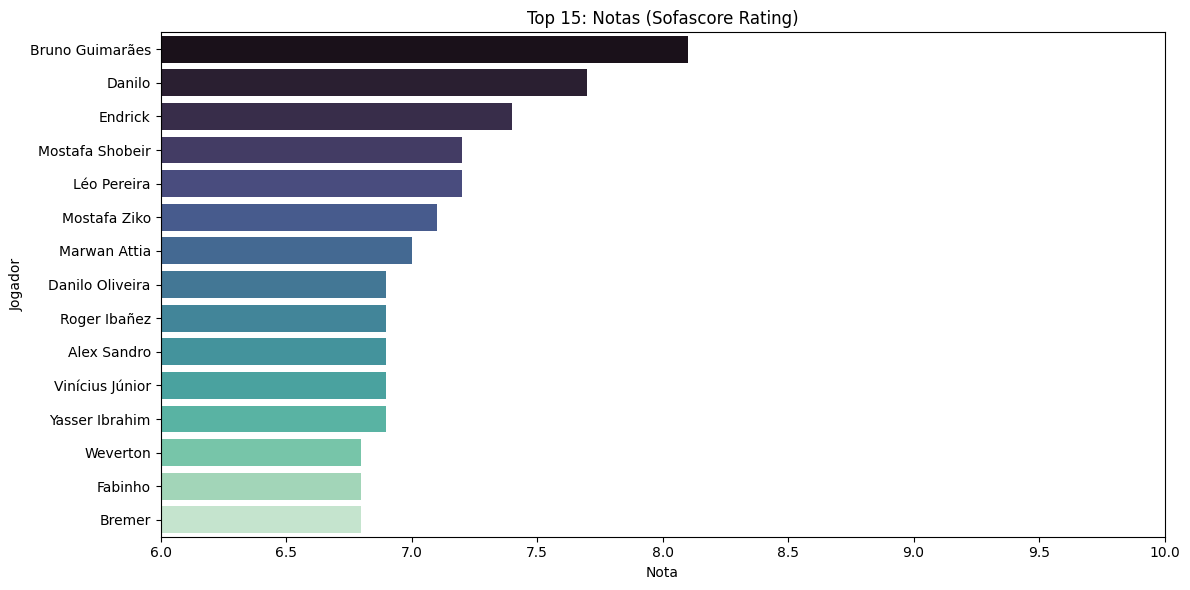

In [11]:
# Plot: Notas (Ratings) dos Jogadores
plt.figure(figsize=(12, 6))
df_sorted_rating = df_plot.sort_values(by='rating', ascending=False).head(15)
sns.barplot(data=df_sorted_rating, x='rating', y='player_name', hue='player_name', legend=False, palette='mako')
plt.title('Top 15: Notas (Sofascore Rating)')
plt.xlabel('Nota')
plt.ylabel('Jogador')
plt.xlim(6, 10)
plt.tight_layout()
plt.show()

## 4. Perfil do Jogador (Widget e Foto)
Aqui trazemos a foto oficial e o widget interativo direto do Sofascore usando HTML puro dentro do Jupyter!

In [88]:
from IPython.display import HTML, display

html_code = f"""
<div style='display: flex; flex-direction: column; align-items: center; padding: 20px;'>
    <iframe id="sofa-player-embed-{TARGET_PLAYER_ID}" src="https://widgets.sofascore.com/pt-BR/embed/player/{TARGET_PLAYER_ID}?widgetTheme=light" style="height:568px!important;max-width:730px!important;width:100%!important; border:none;" frameborder="0" scrolling="no"></iframe>
    <script type="text/javascript" src="https://widgets.sofascore.com/build/js/variables.js"></script>
    <script type="text/javascript" src="https://widgets.sofascore.com/build/js/widget.js"></script>
</div>
"""
display(HTML(html_code))

## 5. Mapa de Passes com Mplsoccer
Vamos pegar os dados detalhados (rating-breakdown) do Bruno Guimarães e desenhar o mapa de passes dele usando a biblioteca `mplsoccer`!

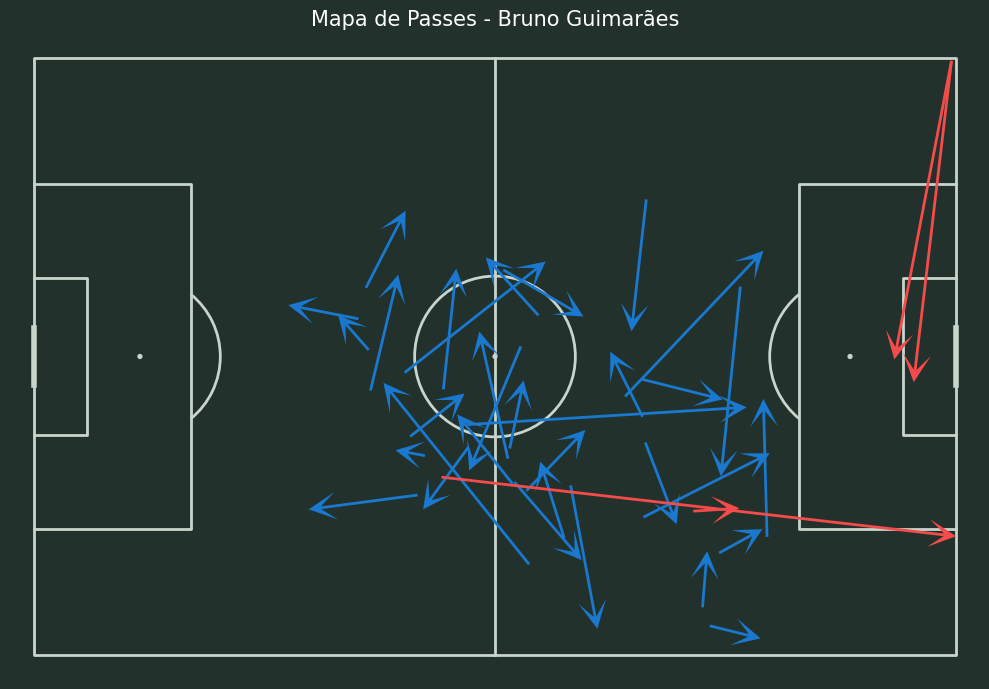

In [12]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Definir o Jogador Alvo (Mude este ID para visualizar outro jogador!)
TARGET_PLAYER_NAME = player_names.get(TARGET_PLAYER_ID, f'Jogador {TARGET_PLAYER_ID}')

# Carregar os dados de eventos do jogador
with open(os.path.join(RAW_DATA_PATH, f'player_{TARGET_PLAYER_ID}_events.json'), 'r', encoding='utf-8') as f:
    events_data = json.load(f)

# Separar coordenadas X e Y (opta usa escala 0-100)
passes = events_data.get('passes', [])

x = [p['playerCoordinates']['x'] for p in passes]
y = [p['playerCoordinates']['y'] for p in passes]
end_x = [p['passEndCoordinates']['x'] for p in passes]
end_y = [p['passEndCoordinates']['y'] for p in passes]

# Determinar a cor baseada no 'outcome' (preciso = azul, impreciso = vermelho)
colors = ['#1A78CF' if p.get('outcome') else '#F64B4B' for p in passes]

# Plotar o campinho
pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# Desenhar as setas dos passes (zip para plotar linha a linha com cores distintas)
for i in range(len(passes)):
    pitch.arrows(x[i], y[i], end_x[i], end_y[i], width=2, headwidth=10, headlength=10, color=colors[i], ax=ax)

ax.set_title(f'Mapa de Passes - {TARGET_PLAYER_NAME}', color='white', fontsize=15)
fig.set_facecolor('#22312b')
plt.show()

## 6. Raio-X Completo: Todas as Ações
Nesta seção, vamos carregar todas as ações espaciais (Chutes, Dribles, Divididas Defensivas e Conduções) em um painel com vários campos!

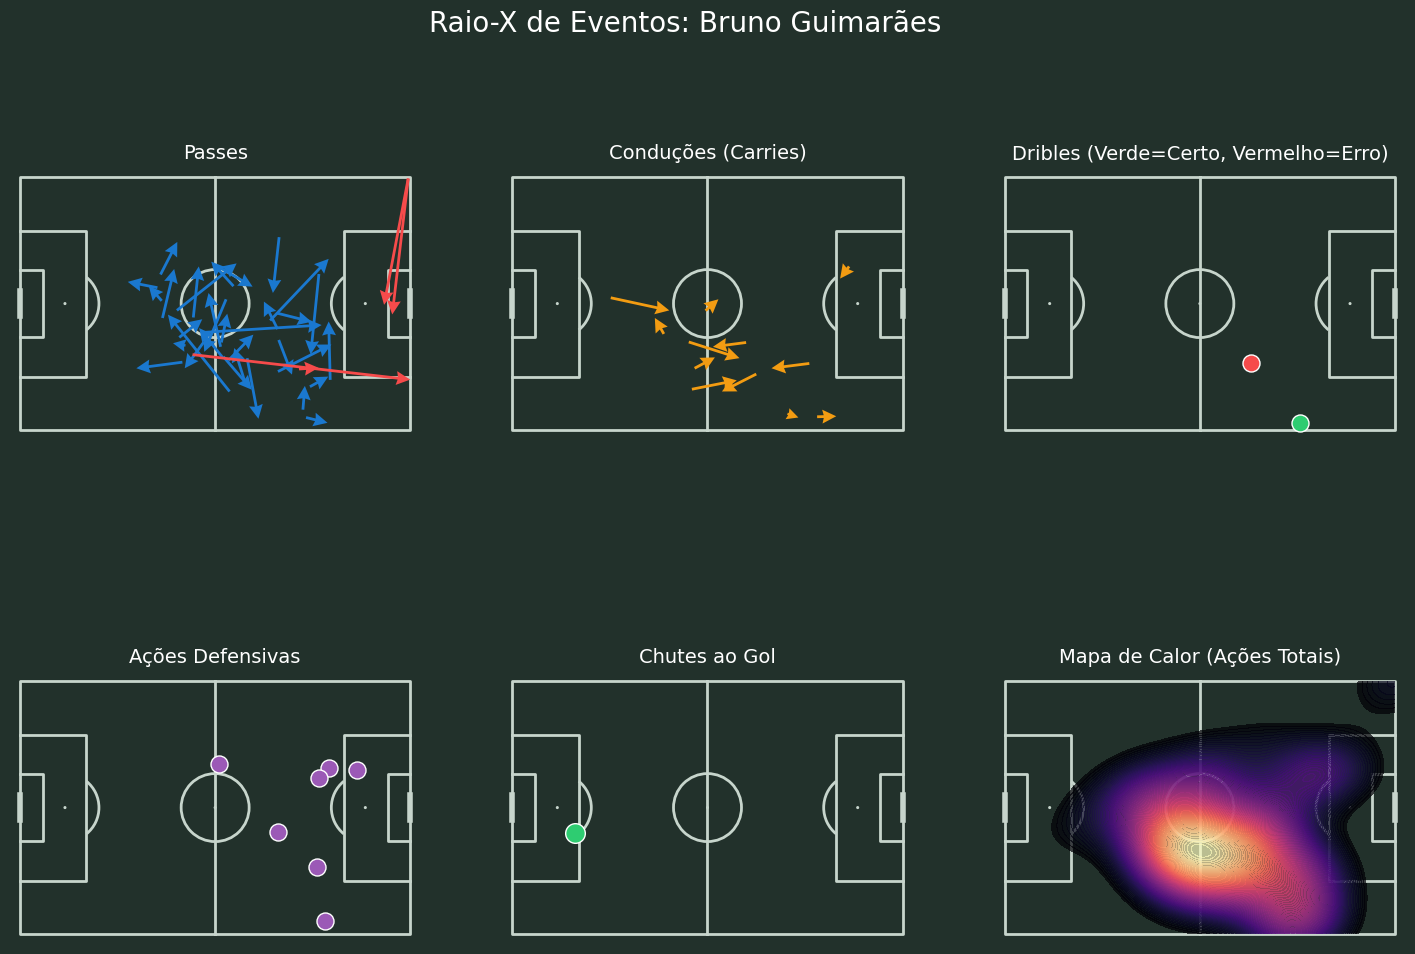

In [13]:
import os
import json
from mplsoccer import Pitch
import matplotlib.pyplot as plt

TARGET_PLAYER_NAME = player_names.get(TARGET_PLAYER_ID, f'Jogador {TARGET_PLAYER_ID}')

# Carregar os dados novamente
with open(os.path.join(RAW_DATA_PATH, f'player_{TARGET_PLAYER_ID}_events.json'), 'r', encoding='utf-8') as f:
    events_data = json.load(f)
with open(os.path.join(RAW_DATA_PATH, f'player_{TARGET_PLAYER_ID}_shotmap.json'), 'r', encoding='utf-8') as f:
    shotmap_data = json.load(f).get('shotmap', [])

# Preparar os dados por categoria
passes = events_data.get('passes', [])
dribbles = events_data.get('dribbles', [])
defensive = events_data.get('defensive', [])
carries = events_data.get('ball-carries', [])
shots = shotmap_data

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.set_facecolor('#22312b')
axs = axs.flatten()

# 1. Passes
pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
pitch.draw(ax=axs[0])
for p in passes:
    color = '#1A78CF' if p.get('outcome') else '#F64B4B'
    pitch.arrows(p['playerCoordinates']['x'], p['playerCoordinates']['y'],
                 p['passEndCoordinates']['x'], p['passEndCoordinates']['y'],
                 width=2, headwidth=5, color=color, ax=axs[0])
axs[0].set_title('Passes', color='white', fontsize=14)

# 2. Conduções (Ball Carries)
pitch.draw(ax=axs[1])
for c in carries:
    pitch.arrows(c['playerCoordinates']['x'], c['playerCoordinates']['y'],
                 c['passEndCoordinates']['x'], c['passEndCoordinates']['y'],
                 width=2, headwidth=5, color='#F39C12', ax=axs[1])
axs[1].set_title('Conduções (Carries)', color='white', fontsize=14)

# 3. Dribles
pitch.draw(ax=axs[2])
for d in dribbles:
    color = '#2ECC71' if d.get('outcome') else '#F64B4B'
    pitch.scatter(d['playerCoordinates']['x'], d['playerCoordinates']['y'],
                  s=150, color=color, edgecolors='white', ax=axs[2])
axs[2].set_title('Dribles (Verde=Certo, Vermelho=Erro)', color='white', fontsize=14)

# 4. Ações Defensivas (Divididas / Desarmes)
pitch.draw(ax=axs[3])
for d in defensive:
    pitch.scatter(d['playerCoordinates']['x'], d['playerCoordinates']['y'],
                  s=150, color='#9B59B6', edgecolors='white', ax=axs[3])
axs[3].set_title('Ações Defensivas', color='white', fontsize=14)

# 5. Chutes (Shotmap)
pitch.draw(ax=axs[4])
for s in shots:
    # Pegar cor baseado no tipo de chute (Goal, Miss, Saved)
    color = '#F1C40F'
    if s.get('shotType') == 'goal': color = '#2ECC71'
    pitch.scatter(s['playerCoordinates']['x'], s['playerCoordinates']['y'],
                  s=200, color=color, edgecolors='white', ax=axs[4])
axs[4].set_title('Chutes ao Gol', color='white', fontsize=14)

# 6. Mapa de Calor (KDE de todas as ações)
pitch.draw(ax=axs[5])
# Juntar todas as coordenadas X e Y
all_x = []
all_y = []
for p in passes: all_x.append(p['playerCoordinates']['x']); all_y.append(p['playerCoordinates']['y'])
for c in carries: all_x.append(c['playerCoordinates']['x']); all_y.append(c['playerCoordinates']['y'])
for d in dribbles: all_x.append(d['playerCoordinates']['x']); all_y.append(d['playerCoordinates']['y'])
for d in defensive: all_x.append(d['playerCoordinates']['x']); all_y.append(d['playerCoordinates']['y'])
for s in shots: all_x.append(s['playerCoordinates']['x']); all_y.append(s['playerCoordinates']['y'])

pitch.kdeplot(all_x, all_y, ax=axs[5], cmap='magma', fill=True, levels=100, alpha=0.7)
axs[5].set_title('Mapa de Calor (Ações Totais)', color='white', fontsize=14)

plt.suptitle(f'Raio-X de Eventos: {TARGET_PLAYER_NAME}', color='white', fontsize=20, y=0.95)
plt.show()